# MDQ Card Classifier — Поиск скрытых предпринимателей

**Задача:** среди карт, помеченных как потребительские, найти тех, кто ведёт предпринимательскую деятельность (hidden entrepreneurs). Такие карты нарушают продуктовые ограничения и несут повышенный регуляторный риск.

**Подход:** три модели с разными предположениями о природе данных — от простого к правильному.

| Раздел | Содержание |
|--------|-----------|
| 0 | Импорты и константы |
| 1–3 | Данные: загрузка, признаки, train/val/test split |
| **4** | **Logistic Regression** — интерпретируемый baseline |
| **5** | **Naive LightGBM** — стандартная бинарная классификация |
| **6** | **PU Bagging Learning** — правильная постановка задачи |
| 7 | Сравнение моделей: ROC, метрики, экспорт кандидатов |


## 0. Импорты и константы

Все глобальные константы собраны в одном месте — это упрощает эксперименты: чтобы поменять целевое число кандидатов или пути к файлам, достаточно изменить одну переменную здесь, а не искать «магические числа» по всему ноутбуку.

`CLEAN_FEATURES` — итоговый набор признаков после отбора по VIF и Forward Selection. `MAIN_PU_COL` — имя колонки с PU-вероятностями, которая кочует между ячейками; вынесено в константу, чтобы не опечататься при изменении.


In [1]:
!pip install -q category_encoders

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    precision_score, recall_score,
)
import category_encoders as ce

RANDOM_STATE = 42

FILE_BUSINESS  = 'business_cards_MDQ.parquet'
FILE_CONSUMER  = 'consumer_cards_MDQ.parquet'
FILE_MERCHANTS = 'merchants_reference.parquet'

# Эталонные значения для proxy-precision: средние показатели бизнес-карт
REF_UNIQUE_MCC          = 14.85
REF_CONCENTRATION_INDEX = 7.71

# Все признаки модели.
# mcc_hhi — Индекс Херфиндаля по MCC (ранее ошибочно назывался mcc_gini)
NUMERIC_FEATURES = [
    'mcc_nunique', 'mcc_hhi', 'concentration_index', 'avg_amount',
    'online_share', 'night_share', 'weekend_share',
    'unique_merchants_ratio', 'mismatch_ratio',
]
CAT_FEATURE  = 'dominant_mcc'
ALL_FEATURES = NUMERIC_FEATURES + [CAT_FEATURE]

# Отобранный набор признаков (по VIF + Forward Selection)
CLEAN_FEATURES = [
    'concentration_index', 'mcc_hhi', 'mcc_nunique',
    'avg_amount', 'online_share', 'night_share', 'weekend_share', CAT_FEATURE,
]
CLEAN_NUM = [f for f in CLEAN_FEATURES if f != CAT_FEATURE]

# PU Learning: количество итераций ансамбля
N_BAGS = 30

# Имя колонки PU-вероятностей — единая точка изменения
MAIN_PU_COL = 'pu_proba'

# Сколько карт-кандидатов мы хотим получить на выходе
TARGET_HIDDEN_CARDS = 100

# MCC-категории, типичные для B2B расходов — используются в proxy-precision
B2B_MCC = {
    '7311','7372','7392','7399','5045','5085','5099','5111','5172','5199',
    '4816','5816','5968','4215','5921','7375','7379','8911','2741','5965',
}

# Колонки результирующего CSV
BASE_EXPORT_COLS     = ['card_number', MAIN_PU_COL, 'ordinary_proba', 'plausible_business']
OPTIONAL_EXPORT_COLS = ['dominant_mcc', 'concentration_index', 'avg_amount', 'weekend_share']

print("Константы инициализированы.")


Константы инициализированы.


## 1. Загрузка и предобработка транзакций

На уровне отдельной транзакции вычисляются четыре бинарных признака-сигнала:

- **is_night** — транзакция между 23:00 и 07:00. Предпринимательские расходы редко бывают ночными.
- **is_weekend** — суббота или воскресенье. Бизнес-операции концентрируются в будни.
- **is_online** — канал `online`. Бизнесы активнее используют онлайн-эквайринг.
- **country_mismatch** — страна карты не совпадает со страной мерчанта. Косвенный признак внешнеэкономической деятельности.

Эти сигналы агрегируются в следующем разделе: доля ночных транзакций, доля выходных и т.д.


In [2]:
def load_merchant_lookup(path: str) -> dict:
    """Загружает словарь merchant_id → merchant_country из справочника мерчантов."""
    ref = pd.read_parquet(path, columns=['merchant_id', 'merchant_country'])
    return ref.set_index('merchant_id')['merchant_country'].to_dict()


def preprocess(path: str, merchant_lookup: dict) -> pd.DataFrame:
    """
    Загружает файл транзакций и добавляет транзакционные сигналы.

    Сигналы вычисляются здесь (до агрегации), потому что после группировки
    по карте мы теряем информацию о времени и канале конкретной транзакции.
    """
    df   = pd.read_parquet(path)
    ts   = pd.to_datetime(df['transaction_timestamp'], errors='coerce')
    hour = ts.dt.hour
    dow  = ts.dt.dayofweek   # Mon=0 … Sun=6

    df['is_night']         = ((hour >= 23) | (hour < 7)).astype('int8')
    df['is_weekend']       = (dow >= 5).astype('int8')
    df['is_online']        = (df['channel'] == 'online').astype('int8')

    merch_country          = df['merchant_id'].map(merchant_lookup)
    df['country_mismatch'] = (
        df['country'].astype(str) != merch_country.astype(str)
    ).astype('int8')

    return df


merchant_lookup = load_merchant_lookup(FILE_MERCHANTS)
business_df     = preprocess(FILE_BUSINESS, merchant_lookup)
consumer_df     = preprocess(FILE_CONSUMER, merchant_lookup)

print(f'Business транзакций : {business_df.shape[0]:,}')
print(f'Consumer транзакций : {consumer_df.shape[0]:,}')
business_df.head()


Business транзакций : 2,997,593
Consumer транзакций : 9,832,487


,transaction_date,transaction_timestamp,transaction_amount_kzt,mcc,merchant_id,channel,bank_name,country,card_number,card_tier,tokenized,is_recurring,is_night,is_weekend,is_online,country_mismatch
0,2025-10-01,2025-10-01 00:00:00,180976,7372,MER_000007,online,Kaspi,US,5228592291438845,Business,False,True,1,0,1,0
1,2025-10-01,2025-10-01 00:00:00,153206,7372,MER_000006,online,Home Credit Bank,US,5201495142193372,Business,False,True,1,0,1,0
2,2025-10-01,2025-10-01 00:00:00,197106,7372,MER_000007,online,Home Credit Bank,US,5201492177677288,Business,False,True,1,0,1,0
3,2025-10-01,2025-10-01 00:01:00,189598,7372,MER_000008,online,Kaspi,US,5176513443697635,Business,False,True,1,0,1,0
4,2025-10-01,2025-10-01 00:03:00,700571,7311,MER_000003,online,Halyk,Russia,5100611967455520,Business,False,True,1,0,1,0


## 2. Инжиниринг признаков на уровне карты

Каждая карта характеризуется агрегированными показателями по всем её транзакциям. Ключевая идея: предприниматели тратят **в большем числе разных категорий** (высокий `mcc_nunique`), но при этом их расходы **концентрированы вокруг одного основного вида деятельности** (высокий `concentration_index = txn_count / unique_merchants`).

**Важно об утечке данных.** Параметры нормализации (границы клиппинга выбросов, список редких MCC-кодов) вычисляются **только по train-транзакциям** через `compute_agg_params()`. Если применить глобальные параметры, val/test данные «знают» что-то о полной выборке — это нарушает честность оценки. Именно для этого `aggregate_cards()` принимает `agg_params` снаружи, а не вычисляет их внутри.


In [3]:
def herfindahl_index(x: pd.Series) -> float:
    """
    Индекс Херфиндаля (HHI) по MCC-кодам карты.

    HHI = сумма квадратов долей. Значение 1.0 означает, что все транзакции
    в одной категории (монополия). Близко к 0 — равномерное распределение.
    Бизнес-карты, как правило, имеют более высокий HHI чем потребительские.
    """
    p = x.value_counts(normalize=True)
    return float((p ** 2).sum())


def safe_mode(x: pd.Series):
    """Возвращает самое частое значение ряда, или NaN если ряд пустой."""
    m = x.mode()
    return m.iloc[0] if not m.empty else np.nan


def compute_agg_params(df: pd.DataFrame, mcc_rare_thresh: float = 0.01) -> dict:
    """
    Вычисляет параметры агрегации по переданным транзакциям.

    Вызывать ТОЛЬКО на train-транзакциях — иначе произойдёт утечка из val/test.
    Возвращает:
      win_low  — нижняя граница клиппинга суммы (1-й перцентиль)
      win_high — верхняя граница клиппинга суммы (99-й перцентиль)
      rare_mcc — MCC с долей < mcc_rare_thresh, которые заменяются на 'other'
    """
    amounts  = df['transaction_amount_kzt'].dropna()
    mcc_freq = df['mcc'].value_counts(normalize=True)
    return {
        'win_low':  float(np.percentile(amounts, 1)),
        'win_high': float(np.percentile(amounts, 99)),
        'rare_mcc': set(mcc_freq[mcc_freq < mcc_rare_thresh].index),
    }


def aggregate_cards(df: pd.DataFrame, name: str,
                    agg_params: dict | None = None) -> pd.DataFrame:
    """
    Агрегирует транзакции до уровня карты, создавая поведенческие признаки.

    agg_params : словарь из compute_agg_params(), вычисленный на train.
                 Если None — параметры берутся из df (только для EDA,
                 в продакшне всегда передавайте train-параметры).
    """
    df = df.copy()
    params = agg_params if agg_params is not None else compute_agg_params(df)

    # Клиппинг выбросов суммы по train-границам (без утечки)
    df['amount_w']    = df['transaction_amount_kzt'].clip(
        lower=params['win_low'], upper=params['win_high']
    )
    # Редкие MCC схлопываются в 'other', чтобы не перегружать WOE-энкодер
    df['mcc_grouped'] = df['mcc'].mask(df['mcc'].isin(params['rare_mcc']), other='other')

    g = df.groupby('card_number', sort=False)
    out = pd.DataFrame({
        'mcc_nunique':      g['mcc'].nunique(),
        'mcc_hhi':          g['mcc'].apply(herfindahl_index),
        'dominant_mcc':     g['mcc_grouped'].apply(safe_mode),
        'txn_count':        g['mcc'].count(),
        'unique_merchants': g['merchant_id'].nunique(),
        'avg_amount':       g['amount_w'].mean(),
        'online_share':     g['is_online'].mean(),
        'night_share':      g['is_night'].mean(),
        'weekend_share':    g['is_weekend'].mean(),
        'mismatch_ratio':   g['country_mismatch'].mean(),
    })
    out['concentration_index']    = out['txn_count'] / out['unique_merchants']
    out['unique_merchants_ratio'] = out['unique_merchants'] / out['txn_count']
    print(f'{name}: {len(out):,} карт')
    return out


# Временная агрегация нужна только чтобы получить card_number для stratified split.
# Признаки будут пересчитаны с честными train-параметрами в разделе 3.
_agg_bus_tmp = aggregate_cards(business_df, 'Business [предварительно]')
_agg_bus_tmp['target'] = 1
_agg_con_tmp = aggregate_cards(consumer_df, 'Consumer [предварительно]')
_agg_con_tmp['target'] = 0

full_df = pd.concat([_agg_bus_tmp, _agg_con_tmp]).reset_index()
print(f'\nВременный датасет: {full_df.shape[0]:,} карт, {full_df.shape[1]} признаков')
print('(признаки будут пересчитаны с train-параметрами в разделе 3)')
full_df.head()


Business [предварительно]: 25,000 карт
Consumer [предварительно]: 80,000 карт

Временный датасет: 105,000 карт, 14 признаков
(признаки будут пересчитаны с train-параметрами в разделе 3)


,card_number,mcc_nunique,mcc_hhi,dominant_mcc,txn_count,unique_merchants,avg_amount,online_share,night_share,weekend_share,mismatch_ratio,concentration_index,unique_merchants_ratio,target
0,5228592291438845,17,0.136282,8931,71,18,180321.365070,0.859155,0.281690,0.112676,0.098592,3.944444,0.253521,1
1,5201495142193372,23,0.159887,8111,147,28,128108.578231,0.823129,0.136054,0.176871,0.136054,5.250000,0.190476,1
2,5201492177677288,21,0.182216,8111,190,25,129912.068211,0.815789,0.126316,0.157895,0.057895,7.600000,0.131579,1
3,5176513443697635,17,0.223616,7311,195,23,213976.347692,0.846154,0.123077,0.138462,0.420513,8.478261,0.117949,1
4,5100611967455520,15,0.178624,5045,125,15,225263.208000,0.880000,0.152000,0.144000,0.064000,8.333333,0.120000,1


## 3. Train / Val / Test split (60 / 20 / 20)

Разбивка на выборки устроена нетривиально — **в четыре шага** — и вот почему.

Простой `train_test_split(full_df)` привёл бы к утечке данных: параметры нормализации (клиппинг суммы, список редких MCC) были бы вычислены по всем транзакциям, включая val/test. Вместо этого:

1. **Предварительный split** — определяем, какие `card_number` попадают в train.
2. **Фильтруем транзакции** — берём только train-транзакции и считаем `agg_params`.
3. **Финальная агрегация** — пересчитываем признаки для всех карт с train-параметрами.
4. **Финальный split** — разбиваем с тем же `random_state`: порядок карт не изменился,    поэтому индексы совпадают с шагом 1.

**WOE-энкодер** обучается один раз на train и используется в Logistic Regression и LightGBM. PU Learning обучает свой WOE-энкодер внутри каждого bag — это корректно, потому что каждый bag видит разное подмножество данных.

**`best_f1_threshold()`** — единая функция выбора порога для всех трёх моделей. Порог ищется по val, применяется к test.


In [4]:
# ── Шаг 1: предварительный split — нужен только для определения card_number в train
X = full_df[ALL_FEATURES]
y = full_df['target']

X_train_tmp, X_temp_tmp, y_train_tmp, y_temp_tmp = train_test_split(
    X, y, test_size=0.40, random_state=RANDOM_STATE, stratify=y)

train_card_numbers_set = set(full_df.loc[X_train_tmp.index, 'card_number'])

# ── Шаг 2: параметры агрегации ТОЛЬКО по train-транзакциям
_train_txns = pd.concat([
    business_df[business_df['card_number'].isin(train_card_numbers_set)],
    consumer_df[consumer_df['card_number'].isin(train_card_numbers_set)],
])
AGG_PARAMS = compute_agg_params(_train_txns)
print(f'Параметры агрегации (только train):')
print(f'  win_low  = {AGG_PARAMS["win_low"]:.1f}')
print(f'  win_high = {AGG_PARAMS["win_high"]:.1f}')
print(f'  rare_mcc = {len(AGG_PARAMS["rare_mcc"])} категорий → "other"')

# ── Шаг 3: финальная агрегация — тот же набор карт, но признаки считаются честно
agg_bus = aggregate_cards(business_df, 'Business', agg_params=AGG_PARAMS)
agg_bus['target'] = 1
agg_con = aggregate_cards(consumer_df, 'Consumer', agg_params=AGG_PARAMS)
agg_con['target'] = 0

full_df = pd.concat([agg_bus, agg_con]).reset_index()

# Q25 avg_amount бизнес-карт из train — порог для proxy-precision эвристики
BUS_AVG_AMOUNT_Q25 = agg_bus.loc[
    agg_bus.index.isin(train_card_numbers_set), 'avg_amount'
].quantile(0.25)
print(f'BUS_AVG_AMOUNT_Q25 (train) = {BUS_AVG_AMOUNT_Q25:.1f}')

# ── Шаг 4: финальный split — тот же random_state → те же индексы что в шаге 1
X = full_df[ALL_FEATURES]
y = full_df['target']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=RANDOM_STATE, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp)

print(f'\nTrain : {len(X_train):,}  ({len(X_train)/len(X):.0%})')
print(f'Val   : {len(X_val):,}   ({len(X_val)/len(X):.0%})')
print(f'Test  : {len(X_test):,}  ({len(X_test)/len(X):.0%})')

# WOE-энкодер обучается один раз на train, применяется к val и test
woe_encoder = ce.WOEEncoder(cols=[CAT_FEATURE]).fit(X_train[[CAT_FEATURE]], y_train)

def woe_encode(df: pd.DataFrame, features: list) -> pd.DataFrame:
    """Применяет обученный woe_encoder к категориальному признаку в переданном наборе."""
    out = df[features].copy()
    if CAT_FEATURE in features:
        out[CAT_FEATURE] = woe_encoder.transform(df[[CAT_FEATURE]])[CAT_FEATURE]
    return out


def best_f1_threshold(
    y_true: np.ndarray,
    y_proba: np.ndarray,
    grid: np.ndarray = None,
) -> tuple:
    """
    Ищет порог с максимальным F1 перебором по сетке.

    Возвращает (threshold, f1_at_threshold).
    По умолчанию проверяет пороги от 0.05 до 0.95 с шагом 0.01.
    """
    if grid is None:
        grid = np.linspace(0.05, 0.95, 91)
    f1s      = [f1_score(y_true, (y_proba > t).astype(int), zero_division=0) for t in grid]
    best_idx = int(np.argmax(f1s))
    return float(grid[best_idx]), float(f1s[best_idx])


print('Split и хелперы готовы.')


Параметры агрегации (только train):
  win_low  = 573.0
  win_high = 846668.3
  rare_mcc = 507 категорий → "other"
Business: 25,000 карт
Consumer: 80,000 карт
BUS_AVG_AMOUNT_Q25 (train) = 121784.8

Train : 63,000  (60%)
Val   : 21,000   (20%)
Test  : 21,000  (20%)
Split и хелперы готовы.


---
## Модель 1 — Logistic Regression

**Зачем нужен этот baseline?** Логистическая регрессия — самая интерпретируемая модель: каждый признак имеет коэффициент, который можно показать бизнес-аналитику. Если LightGBM или PU дают схожий AUC, но их объяснить сложно, LogReg — хороший кандидат для продакшна.

Категориальный признак `dominant_mcc` кодируется WOE внутри Pipeline — это гарантирует, что трансформация не получает информацию о val/test. После WOE все признаки масштабируются `StandardScaler`, что необходимо для регуляризации логистической регрессии.


### 4.1 Обучение

In [5]:
logreg_pipe = Pipeline([
    ('pre', ColumnTransformer([
        ('woe', ce.WOEEncoder(), [CAT_FEATURE]),
        ('num', 'passthrough',   CLEAN_NUM),
    ])),
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])
logreg_pipe.fit(X_train[CLEAN_FEATURES], y_train)

lr_val_prob            = logreg_pipe.predict_proba(X_val[CLEAN_FEATURES])[:, 1]
lr_best_thr, lr_val_f1 = best_f1_threshold(y_val, lr_val_prob)

print(f'LogReg обучен.')
print(f'Лучший порог на val : {lr_best_thr:.3f}  (F1_val = {lr_val_f1:.4f})')


LogReg обучен.
Лучший порог на val : 0.530  (F1_val = 0.9954)


### 4.2 Метрики на Test

LOGISTIC REGRESSION — TEST METRICS
  ROC-AUC     : 0.9999
  Accuracy    : 0.9978
  F1 (binary) : 0.9953
  F1 (macro)  : 0.9969
  Precision   : 0.9958
  Recall      : 0.9948
  Threshold   : 0.530

              precision    recall  f1-score   support

    consumer       1.00      1.00      1.00     16000
    business       1.00      0.99      1.00      5000

    accuracy                           1.00     21000
   macro avg       1.00      1.00      1.00     21000
weighted avg       1.00      1.00      1.00     21000



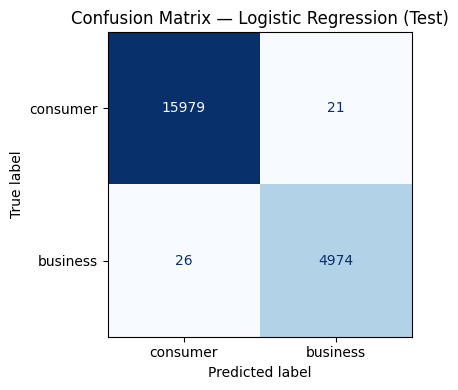

In [6]:
lr_test_prob = logreg_pipe.predict_proba(X_test[CLEAN_FEATURES])[:, 1]
lr_test_pred = (lr_test_prob > lr_best_thr).astype(int)

lr_auc      = roc_auc_score(y_test, lr_test_prob)
lr_acc      = accuracy_score(y_test, lr_test_pred)
lr_f1_bin   = f1_score(y_test, lr_test_pred, zero_division=0)
lr_f1_macro = f1_score(y_test, lr_test_pred, average='macro', zero_division=0)
lr_prec     = precision_score(y_test, lr_test_pred, zero_division=0)
lr_rec      = recall_score(y_test, lr_test_pred, zero_division=0)

print('=' * 55)
print('LOGISTIC REGRESSION — TEST METRICS')
print('=' * 55)
print(f'  ROC-AUC     : {lr_auc:.4f}')
print(f'  Accuracy    : {lr_acc:.4f}')
print(f'  F1 (binary) : {lr_f1_bin:.4f}')
print(f'  F1 (macro)  : {lr_f1_macro:.4f}')
print(f'  Precision   : {lr_prec:.4f}')
print(f'  Recall      : {lr_rec:.4f}')
print(f'  Threshold   : {lr_best_thr:.3f}')
print()
print(classification_report(y_test, lr_test_pred, target_names=['consumer', 'business']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, lr_test_pred),
    display_labels=['consumer', 'business']
).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Logistic Regression (Test)')
plt.tight_layout()
plt.show()


### 4.3 Коэффициенты модели

Красные столбцы — признаки, которые увеличивают P(бизнес), синие — уменьшают. Это главное преимущество логрегрессии: можно сразу объяснить, почему конкретная карта получила высокий скор.


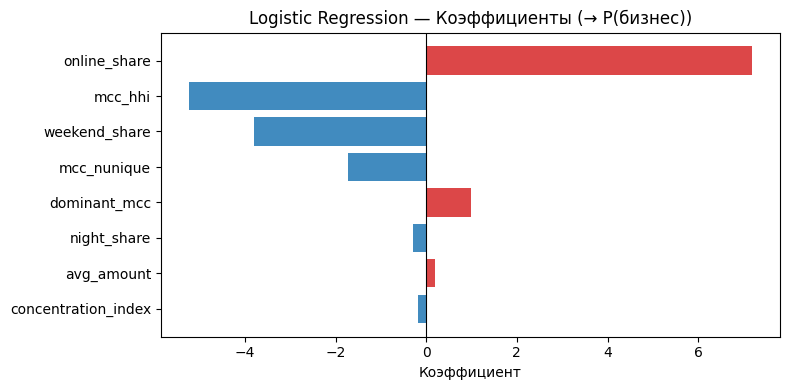

,feature,coef
0,online_share,7.184979
1,mcc_hhi,-5.230686
2,weekend_share,-3.791307
3,mcc_nunique,-1.718913
4,dominant_mcc,0.985842
5,night_share,-0.280626
6,avg_amount,0.186617
7,concentration_index,-0.175169


In [7]:
coef_names = [CAT_FEATURE] + CLEAN_NUM
coef_vals  = logreg_pipe.named_steps['clf'].coef_[0]

lr_coef_df = (
    pd.DataFrame({'feature': coef_names, 'coef': coef_vals})
    .sort_values('coef', key=abs, ascending=False)
    .reset_index(drop=True)
)

colors_coef = ['#d62728' if v > 0 else '#1f77b4' for v in lr_coef_df['coef']]
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(lr_coef_df['feature'], lr_coef_df['coef'], color=colors_coef, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression — Коэффициенты (→ P(бизнес))')
ax.set_xlabel('Коэффициент')
ax.invert_yaxis()
plt.tight_layout()
plt.show()
display(lr_coef_df)


---
## Модель 2 — Naive LightGBM (Standard Classification)

Стандартный бинарный градиентный бустинг. «Naive» — потому что модель предполагает, что все карты в классе 0 **действительно** являются потребителями. На деле это не так: часть потребительских карт — скрытые предприниматели. Модель неявно обучается штрафовать их за высокую вероятность, что снижает recall.

LightGBM c `n_estimators=1000` и `early_stopping(50)` — стандартная практика: задаём большой лимит итераций, а останавливаемся когда val-AUC перестаёт расти.


### 5.1 Обучение

In [8]:
lgb_clf = lgb.LGBMClassifier(
    n_estimators=1000, learning_rate=0.05, num_leaves=31,
    random_state=RANDOM_STATE, verbosity=-1,
)
lgb_clf.fit(
    woe_encode(X_train, ALL_FEATURES), y_train,
    eval_set=[(woe_encode(X_val, ALL_FEATURES), y_val)],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(50, verbose=False)],
)
print(f'LightGBM обучен. best_iteration = {lgb_clf.best_iteration_}')

lgb_val_prob             = lgb_clf.predict_proba(woe_encode(X_val, ALL_FEATURES))[:, 1]
lgb_best_thr, lgb_val_f1 = best_f1_threshold(y_val, lgb_val_prob)
print(f'Лучший порог на val : {lgb_best_thr:.3f}  (F1_val = {lgb_val_f1:.4f})')


LightGBM обучен. best_iteration = 202
Лучший порог на val : 0.180  (F1_val = 0.9982)


### 5.2 Метрики на Test

NAIVE LIGHTGBM — TEST METRICS
  ROC-AUC     : 1.0000
  Accuracy    : 0.9989
  F1 (binary) : 0.9976
  F1 (macro)  : 0.9984
  Precision   : 0.9974
  Recall      : 0.9978
  Threshold   : 0.180

              precision    recall  f1-score   support

    consumer       1.00      1.00      1.00     16000
    business       1.00      1.00      1.00      5000

    accuracy                           1.00     21000
   macro avg       1.00      1.00      1.00     21000
weighted avg       1.00      1.00      1.00     21000



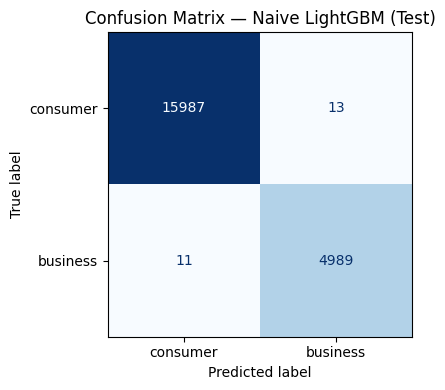

In [9]:
lgb_test_prob = lgb_clf.predict_proba(woe_encode(X_test, ALL_FEATURES))[:, 1]
lgb_test_pred = (lgb_test_prob > lgb_best_thr).astype(int)

lgb_auc      = roc_auc_score(y_test, lgb_test_prob)
lgb_acc      = accuracy_score(y_test, lgb_test_pred)
lgb_f1_bin   = f1_score(y_test, lgb_test_pred, zero_division=0)
lgb_f1_macro = f1_score(y_test, lgb_test_pred, average='macro', zero_division=0)
lgb_prec     = precision_score(y_test, lgb_test_pred, zero_division=0)
lgb_rec      = recall_score(y_test, lgb_test_pred, zero_division=0)

print('=' * 55)
print('NAIVE LIGHTGBM — TEST METRICS')
print('=' * 55)
print(f'  ROC-AUC     : {lgb_auc:.4f}')
print(f'  Accuracy    : {lgb_acc:.4f}')
print(f'  F1 (binary) : {lgb_f1_bin:.4f}')
print(f'  F1 (macro)  : {lgb_f1_macro:.4f}')
print(f'  Precision   : {lgb_prec:.4f}')
print(f'  Recall      : {lgb_rec:.4f}')
print(f'  Threshold   : {lgb_best_thr:.3f}')
print()
print(classification_report(y_test, lgb_test_pred, target_names=['consumer', 'business']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, lgb_test_pred),
    display_labels=['consumer', 'business']
).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Naive LightGBM (Test)')
plt.tight_layout()
plt.show()


### 5.3 Feature Importance

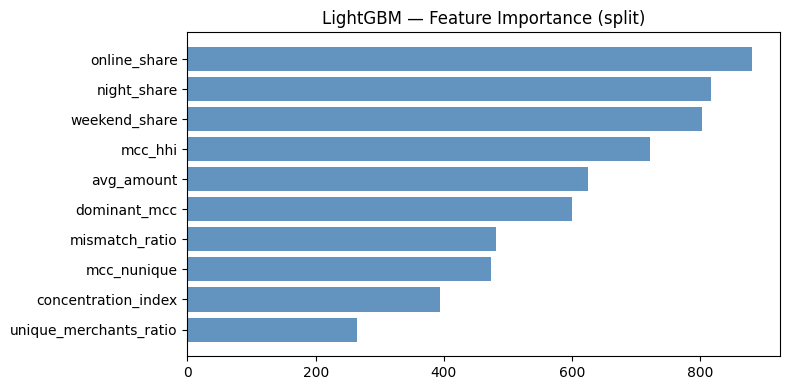

,feature,importance
0,online_share,880
1,night_share,817
2,weekend_share,802
3,mcc_hhi,722
4,avg_amount,625
5,dominant_mcc,600
6,mismatch_ratio,481
7,mcc_nunique,474
8,concentration_index,394
9,unique_merchants_ratio,265


In [10]:
lgb_importance = (
    pd.DataFrame({
        'feature':    woe_encode(X_train, ALL_FEATURES).columns.tolist(),
        'importance': lgb_clf.feature_importances_,
    })
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(lgb_importance['feature'], lgb_importance['importance'],
        color='steelblue', alpha=0.85)
ax.set_title('LightGBM — Feature Importance (split)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()
display(lgb_importance)


---
## Модель 3 — PU Bagging Learning (Mordelet & Vert, 2014)

### Постановка задачи

Классические модели обучаются на метках `business=1` и `consumer=0`. Но реальность сложнее: часть карт в классе `consumer` — это предприниматели, которые **просто не были выявлены**. Если мы обучаем модель на этих «грязных» метках, она получает противоречивый сигнал: «учись, что это обычный потребитель» — для карты, которая на деле бизнес.

PU Learning (Positive-Unlabeled) формулирует задачу честно:
- **P (Positive)** — бизнес-карты, метка надёжна ✅
- **U (Unlabeled)** — потребительские карты, метка **ненадёжна**: среди них могут быть скрытые бизнесы ⚠️

### Алгоритм Bagging PU

Каждый из `N_BAGS` мешков работает так:
1. Берём **все** бизнес-карты из train как позитивы (`P`).
2. Случайно сэмплируем `|P|` карт из потребительских как «предполагаемые негативы» (`U_i`).
3. Обучаем LightGBM на `P ∪ U_i`.
4. Повторяем `N_BAGS` раз с разными подвыборками.
5. Итоговая вероятность = **среднее** по всем мешкам.

Карта, которая стабильно получает высокую вероятность во **всех** мешках — почти точно скрытый предприниматель, потому что в большинстве подвыборок она не попала в «негативы» и модель не училась её занижать.


### 6.1 Вспомогательные функции

In [11]:
def _prepare_for_lgbm(
    X_pos: pd.DataFrame,
    X_neg: pd.DataFrame,
    features: list,
    cat_feature: str = CAT_FEATURE,
    random_state: int = RANDOM_STATE,
    n_estimators: int = 200,
    num_leaves: int = 31,
    learning_rate: float = 0.05,
) -> Pipeline:
    """
    Обучает одну bag-модель на P + U_i и возвращает обученный Pipeline.

    WOE-энкодер обучается внутри этого bag — не используется глобальный woe_encoder.
    Это правильно: каждый bag видит разный состав данных.
    Гиперпараметры LightGBM вынесены в аргументы для grid search в разделе 6.8.
    """
    n_pos = len(X_pos)
    X_bag = pd.concat([X_pos, X_neg], ignore_index=True)
    y_bag = np.array([1] * n_pos + [0] * n_pos)

    num_f        = [f for f in features if f != cat_feature]
    transformers = []
    if cat_feature in features:
        transformers.append(('woe', ce.WOEEncoder(), [cat_feature]))
    transformers.append(('num', 'passthrough', num_f))

    model = Pipeline([
        ('pre', ColumnTransformer(transformers)),
        ('clf', lgb.LGBMClassifier(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            num_leaves=num_leaves,
            random_state=random_state,
            verbosity=-1,
        )),
    ])
    model.fit(X_bag, y_bag)
    return model


def bagging_pu(
    X_pos: pd.DataFrame,
    X_unl: pd.DataFrame,
    X_score: pd.DataFrame,
    features: list,
    n_bags: int = N_BAGS,
    random_state: int = RANDOM_STATE,
    return_models: bool = False,
    n_estimators: int = 200,
    num_leaves: int = 31,
    learning_rate: float = 0.05,
):
    """
    Bagging PU Learning (Mordelet & Vert, 2014).

    Обучает ансамбль bag-моделей, каждая на P + случайной подвыборке U.
    Финальная вероятность — среднее по всем мешкам.

    Parameters
    ----------
    X_pos         : бизнес-карты из train (надёжные позитивы)
    X_unl         : потребительские карты из train (загрязнённый класс)
    X_score       : датасет, для которого нужны вероятности
    features      : список признаков
    n_bags        : количество итераций ансамбля
    return_models : если True — возвращает (mean_probas, models)
    """
    X_pos_r   = X_pos[features].reset_index(drop=True)
    X_unl_r   = X_unl[features].reset_index(drop=True)
    X_score_f = X_score[features].reset_index(drop=True)

    rng        = np.random.RandomState(random_state)
    n_pos      = len(X_pos_r)
    all_probas = np.zeros((n_bags, len(X_score_f)))
    models     = []

    for bag in range(n_bags):
        # Каждый bag получает свою уникальную подвыборку негативов
        neg_idx = rng.choice(len(X_unl_r), size=n_pos, replace=False)
        X_neg   = X_unl_r.iloc[neg_idx].reset_index(drop=True)

        model = _prepare_for_lgbm(
            X_pos=X_pos_r, X_neg=X_neg,
            features=features, cat_feature=CAT_FEATURE,
            random_state=random_state + bag,   # разный seed = разная инициализация деревьев
            n_estimators=n_estimators,
            num_leaves=num_leaves,
            learning_rate=learning_rate,
        )
        all_probas[bag] = model.predict_proba(X_score_f)[:, 1]
        models.append(model)

        if (bag + 1) % 5 == 0:
            print(f'  Bag {bag+1:2d}/{n_bags}   mean_prob = {all_probas[bag].mean():.3f}')

    mean_probas = all_probas.mean(axis=0)
    if return_models:
        return mean_probas, models
    return mean_probas


def predict_bagging_pu(
    models: list,
    X: pd.DataFrame,
    features: list,
) -> np.ndarray:
    """Инференс на новых данных: усредняет вероятности по всем bag-моделям."""
    X_f        = X[features].reset_index(drop=True)
    all_probas = np.zeros((len(models), len(X_f)))
    for i, model in enumerate(models):
        all_probas[i] = model.predict_proba(X_f)[:, 1]
    return all_probas.mean(axis=0)


print('PU-функции определены.')


PU-функции определены.


### 6.2 Обучение PU-ансамбля

In [12]:
# Потребительские карты для скоринга (все, не только train)
agg_con_reset = agg_con.reset_index()   # card_number из индекса → в колонку

# Позитивы и unlabeled — только из train-выборки
train_card_numbers = set(full_df.loc[X_train.index, 'card_number'])
X_pos_pu = agg_bus[agg_bus.index.isin(train_card_numbers)].copy()
X_unl_pu = agg_con[agg_con.index.isin(train_card_numbers)].copy()

print(f'Позитивов (бизнес) в train : {len(X_pos_pu):,}')
print(f'Unlabeled (физлица) в train: {len(X_unl_pu):,}')
print(f'Соотношение U/P            : {len(X_unl_pu)/len(X_pos_pu):.1f}x')
print(f'Физлиц для скоринга        : {len(agg_con_reset):,}')
print(f'\nЗапускаем Bagging PU ({N_BAGS} мешков)...')

pu_probas_con, pu_models = bagging_pu(
    X_pos=X_pos_pu,
    X_unl=X_unl_pu,
    X_score=agg_con_reset,
    features=CLEAN_FEATURES,
    return_models=True,
)
agg_con_reset[MAIN_PU_COL] = pu_probas_con

print(f'\nРаспределение {MAIN_PU_COL} по физлицам:')
display(agg_con_reset[MAIN_PU_COL].describe().round(4))


Позитивов (бизнес) в train : 15,000
Unlabeled (физлица) в train: 48,000
Соотношение U/P            : 3.2x
Физлиц для скоринга        : 80,000

Запускаем Bagging PU (30 мешков)...
  Bag  5/30   mean_prob = 0.001
  Bag 10/30   mean_prob = 0.001
  Bag 15/30   mean_prob = 0.001
  Bag 20/30   mean_prob = 0.001
  Bag 25/30   mean_prob = 0.001
  Bag 30/30   mean_prob = 0.001

Распределение pu_proba по физлицам:


count    80000.0000
mean         0.0014
std          0.0282
min          0.0000
25%          0.0000
50%          0.0000
75%          0.0000
max          1.0000
Name: pu_proba, dtype: float64

### 6.3 Метрики PU Learning на Test

> **Почему PU вообще оценивается через Confusion Matrix?**
>
> Это диагностический трюк для сравнения с другими моделями, а не настоящая оценка.
>
> `y_test` содержит **грязные метки**: часть физлиц помечена как `0`, > хотя реально является бизнесом. Тем не менее, применив `predict_bagging_pu` к test-сету, > мы получаем вероятности на размеченных данных и можем построить матрицу ошибок.
>
> **Интерпретация требует осторожности:**
> - **FP** (физлицо помечено как бизнес) — часть из них реально скрытые предприниматели ⚠️
> - Поэтому если PU даёт больше «FP» чем LightGBM — это **успех**, а не ошибка.
>
> Настоящее качество PU измеряется через **Precision@K** и **proxy-precision** (раздел 6.5).


PU LEARNING — TEST METRICS
  ROC-AUC     : 1.0000
  Accuracy    : 0.9988
  F1 (binary) : 0.9975
  F1 (macro)  : 0.9984
  Precision   : 0.9966
  Recall      : 0.9984
  Threshold   : 0.600

              precision    recall  f1-score   support

    consumer       1.00      1.00      1.00     16000
    business       1.00      1.00      1.00      5000

    accuracy                           1.00     21000
   macro avg       1.00      1.00      1.00     21000
weighted avg       1.00      1.00      1.00     21000



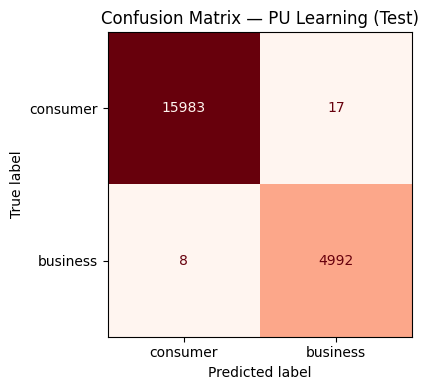

In [13]:
pu_test_prob = predict_bagging_pu(pu_models, X_test, CLEAN_FEATURES)
pu_val_prob  = predict_bagging_pu(pu_models, X_val,  CLEAN_FEATURES)

pu_best_thr, pu_val_f1 = best_f1_threshold(y_val, pu_val_prob)
pu_test_pred            = (pu_test_prob > pu_best_thr).astype(int)

pu_auc      = roc_auc_score(y_test, pu_test_prob)
pu_acc      = accuracy_score(y_test, pu_test_pred)
pu_f1_bin   = f1_score(y_test, pu_test_pred, zero_division=0)
pu_f1_macro = f1_score(y_test, pu_test_pred, average='macro', zero_division=0)
pu_prec     = precision_score(y_test, pu_test_pred, zero_division=0)
pu_rec      = recall_score(y_test, pu_test_pred, zero_division=0)

print('=' * 55)
print('PU LEARNING — TEST METRICS')
print('=' * 55)
print(f'  ROC-AUC     : {pu_auc:.4f}')
print(f'  Accuracy    : {pu_acc:.4f}')
print(f'  F1 (binary) : {pu_f1_bin:.4f}')
print(f'  F1 (macro)  : {pu_f1_macro:.4f}')
print(f'  Precision   : {pu_prec:.4f}')
print(f'  Recall      : {pu_rec:.4f}')
print(f'  Threshold   : {pu_best_thr:.3f}')
print()
print(classification_report(y_test, pu_test_pred, target_names=['consumer', 'business']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, pu_test_pred),
    display_labels=['consumer', 'business']
).plot(ax=ax, cmap='Reds', colorbar=False)
ax.set_title('Confusion Matrix — PU Learning (Test)')
plt.tight_layout()
plt.show()


### 6.4 Анализ физлиц — скрытые предприниматели

Вместо фиксированного порога (например, 0.5) используется **динамический порог топ-N**: берём `TARGET_HIDDEN_CARDS` карт с наибольшим PU-скором. Это операционно удобнее: команда аналитиков говорит «мы готовы проверить 100 карт», а не «выставьте порог 0.63».


In [14]:
# Обычная вероятность от LightGBM для тех же карт — для сравнения в разделе 7
agg_con_reset['ordinary_proba'] = lgb_clf.predict_proba(
    woe_encode(agg_con_reset, ALL_FEATURES)
)[:, 1]

# Динамический порог: n-й наибольший скор = минимум для попадания в топ
sorted_probas = agg_con_reset[MAIN_PU_COL].sort_values(ascending=False)
PU_THRESHOLD  = float(sorted_probas.iloc[TARGET_HIDDEN_CARDS - 1])

print(f'TARGET_HIDDEN_CARDS : {TARGET_HIDDEN_CARDS}')
print(f'Динамический порог  : {PU_THRESHOLD:.4f}  '
      f'(минимальный скор в топ-{TARGET_HIDDEN_CARDS})')

# На случай ties — head(TARGET_HIDDEN_CARDS) гарантирует ровно N кандидатов
hidden_pu = (
    agg_con_reset[agg_con_reset[MAIN_PU_COL] >= PU_THRESHOLD]
    .sort_values(MAIN_PU_COL, ascending=False)
    .head(TARGET_HIDDEN_CARDS)
    .copy()
)

print(f'Итого кандидатов    : {len(hidden_pu):,} '
      f'({len(hidden_pu) / len(agg_con_reset):.2%} от всех физлиц)')
display(hidden_pu[[
    'card_number', MAIN_PU_COL, 'ordinary_proba',
    'concentration_index', 'mcc_nunique', 'avg_amount', 'weekend_share'
]].head(15))


TARGET_HIDDEN_CARDS : 100
Динамический порог  : 0.4780  (минимальный скор в топ-100)
Итого кандидатов    : 100 (0.12% от всех физлиц)


,card_number,pu_proba,ordinary_proba,concentration_index,mcc_nunique,avg_amount,weekend_share
77408,5201491354169846,0.999974,0.999914,6.500000,8,217102.438462,0.076923
65960,5211556274611016,0.999943,0.999804,4.142857,13,404728.370690,0.155172
76020,5368291791007503,0.999923,0.999399,12.285714,7,281608.097674,0.186047
30143,5100611889266872,0.999922,0.998227,16.571429,7,168466.099138,0.120690
46785,5176512938679108,0.999894,0.998517,14.714286,7,146180.718447,0.106796
72543,5168266771002940,0.999638,0.996363,12.714286,7,327799.897753,0.112360
43893,5441020944586282,0.999514,0.993668,6.750000,8,224755.738889,0.111111
65749,5486737863418710,0.998287,0.986690,12.833333,6,152134.727273,0.129870
34766,5338479914183213,0.995985,0.944845,8.000000,7,236368.998214,0.142857
70187,5486025422486893,0.990457,0.973408,5.571429,7,184827.597436,0.128205


### 6.4b График PU-скоров — распределение и топ-кандидаты

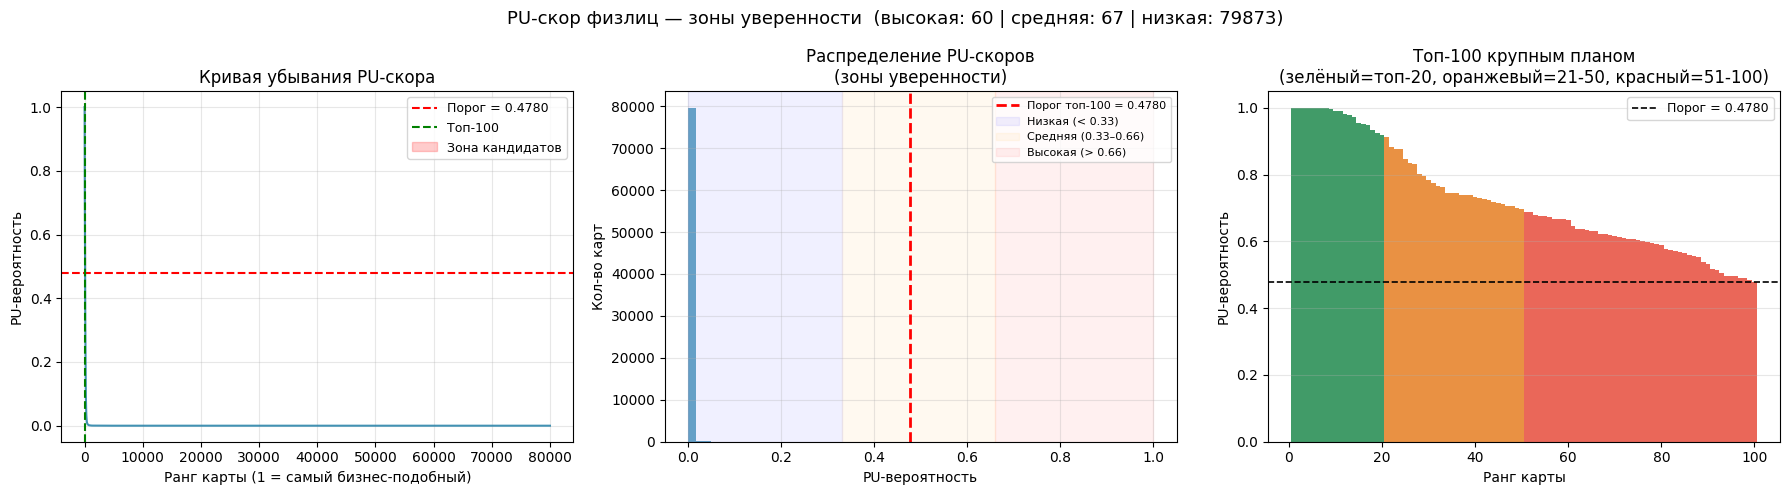


Статистика PU-скора:


count    80000.0000
mean         0.0014
std          0.0282
min          0.0000
25%          0.0000
50%          0.0000
75%          0.0000
max          1.0000
Name: pu_proba, dtype: float64


Порог для топ-100: 0.4780
Скор 20-й карты  : 0.9179
Скор 50-й карты  : 0.6964
Скор 100-й карты : 0.4780


In [15]:
ranked = (
    agg_con_reset[[MAIN_PU_COL]]
    .sort_values(MAIN_PU_COL, ascending=False)
    .reset_index(drop=True)
    .assign(rank=lambda df: df.index + 1)
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# График 1: кривая убывания PU-скора по рангу карты
ax1 = axes[0]
ax1.plot(ranked['rank'], ranked[MAIN_PU_COL], color='#2E86AB', linewidth=1.5, alpha=0.9)
ax1.axhline(PU_THRESHOLD, color='red', linestyle='--', linewidth=1.5,
            label=f'Порог = {PU_THRESHOLD:.4f}')
ax1.axvline(TARGET_HIDDEN_CARDS, color='green', linestyle='--', linewidth=1.5,
            label=f'Топ-{TARGET_HIDDEN_CARDS}')
ax1.fill_between(
    ranked.loc[ranked['rank'] <= TARGET_HIDDEN_CARDS, 'rank'],
    ranked.loc[ranked['rank'] <= TARGET_HIDDEN_CARDS, MAIN_PU_COL],
    PU_THRESHOLD, alpha=0.20, color='red', label='Зона кандидатов'
)
ax1.set_xlabel('Ранг карты (1 = самый бизнес-подобный)')
ax1.set_ylabel('PU-вероятность')
ax1.set_title('Кривая убывания PU-скора')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# График 2: гистограмма с зонами уверенности
ax2 = axes[1]
ax2.hist(ranked[MAIN_PU_COL], bins=60, color='#2E86AB', alpha=0.7)
ax2.axvline(PU_THRESHOLD, color='red', linestyle='--', linewidth=2,
            label=f'Порог топ-{TARGET_HIDDEN_CARDS} = {PU_THRESHOLD:.4f}')
ax2.axvspan(0.00, 0.33, alpha=0.06, color='blue',   label='Низкая (< 0.33)')
ax2.axvspan(0.33, 0.66, alpha=0.06, color='orange', label='Средняя (0.33–0.66)')
ax2.axvspan(0.66, 1.00, alpha=0.06, color='red',    label='Высокая (> 0.66)')
ax2.set_xlabel('PU-вероятность')
ax2.set_ylabel('Кол-во карт')
ax2.set_title('Распределение PU-скоров\n(зоны уверенности)')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

# График 3: топ-100 кандидатов крупным планом — цвет по зоне рейтинга
ax3     = axes[2]
top_n   = ranked.head(TARGET_HIDDEN_CARDS)
colors_rank = [
    '#1f8a4e' if r <= 20 else '#e67e22' if r <= 50 else '#e74c3c'
    for r in top_n['rank']
]
ax3.bar(top_n['rank'], top_n[MAIN_PU_COL], color=colors_rank, alpha=0.85, width=1.0)
ax3.axhline(PU_THRESHOLD, color='black', linestyle='--', linewidth=1.2,
            label=f'Порог = {PU_THRESHOLD:.4f}')
ax3.set_xlabel('Ранг карты')
ax3.set_ylabel('PU-вероятность')
ax3.set_title(f'Топ-{TARGET_HIDDEN_CARDS} крупным планом\n'
              '(зелёный=топ-20, оранжевый=21-50, красный=51-100)')
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3, axis='y')

n_high = int((agg_con_reset[MAIN_PU_COL] > 0.66).sum())
n_mid  = int(((agg_con_reset[MAIN_PU_COL] > 0.33) &
              (agg_con_reset[MAIN_PU_COL] <= 0.66)).sum())
n_low  = int((agg_con_reset[MAIN_PU_COL] <= 0.33).sum())

plt.suptitle(
    f'PU-скор физлиц — зоны уверенности  '
    f'(высокая: {n_high} | средняя: {n_mid} | низкая: {n_low})',
    fontsize=13
)
plt.tight_layout()
plt.show()

print(f'\nСтатистика PU-скора:')
display(agg_con_reset[MAIN_PU_COL].describe().round(4))
print(f'\nПорог для топ-{TARGET_HIDDEN_CARDS}: {PU_THRESHOLD:.4f}')
print(f'Скор 20-й карты  : {ranked.iloc[19][MAIN_PU_COL]:.4f}')
print(f'Скор 50-й карты  : {ranked.iloc[49][MAIN_PU_COL]:.4f}')
print(f'Скор 100-й карты : {ranked.iloc[99][MAIN_PU_COL]:.4f}')


### 6.5 Proxy-precision (B2B-эвристика)

Поскольку у нас нет ground truth для физлиц, мы оцениваем качество топ-кандидатов через **эвристику бизнес-правдоподобия**: карта считается «похожей на бизнес», если выполняются четыре условия одновременно:

1. `concentration_index` ≥ 70% от эталонного — высокая транзакционная нагрузка на мерчанта
2. `avg_amount` ≥ Q25 бизнес-карт — суммы не ниже нижней границы бизнес-диапазона
3. `weekend_share` ≤ 20% — бизнес-операции редко происходят в выходные
4. `dominant_mcc` входит в B2B-категории — основная трата в типичном бизнес-сегменте

`proxy_precision = доля правдоподобных / все кандидаты`. Это не точность модели (ground truth неизвестен), но хороший операционный индикатор.


In [16]:
def looks_like_business(row) -> bool:
    """
    Эвристика: возвращает True если карта соответствует профилю бизнес-расходов.

    Использует BUS_AVG_AMOUNT_Q25 и REF_CONCENTRATION_INDEX из глобального контекста —
    оба вычислены по train-данным, утечки нет.
    """
    return (
        row['concentration_index'] >= 0.7 * REF_CONCENTRATION_INDEX
        and row['avg_amount']       >= BUS_AVG_AMOUNT_Q25
        and row['weekend_share']    <= 0.20
        and str(row['dominant_mcc']) in B2B_MCC
    )


hidden_pu['plausible_business'] = hidden_pu.apply(looks_like_business, axis=1)
proxy_precision = hidden_pu['plausible_business'].mean()

print(f'Топ-кандидатов всего        : {len(hidden_pu):,}')
print(f'Правдоподобны по эвристике  : {hidden_pu["plausible_business"].sum()}')
print(f'Proxy-precision (B2B)       : {proxy_precision:.2%}')
print()
print('Топ dominant_mcc среди кандидатов:')
display(hidden_pu['dominant_mcc'].value_counts().head(8))


Топ-кандидатов всего        : 100
Правдоподобны по эвристике  : 25
Proxy-precision (B2B)       : 25.00%

Топ dominant_mcc среди кандидатов:


dominant_mcc
7311     39
other    26
4121      4
4816      3
5099      3
5812      3
5921      3
5499      3
Name: count, dtype: int64

### 6.6 Feature Importance PU — агрегация по всем мешкам

В PU Bagging нет единой модели — есть `N_BAGS` отдельных LightGBM. Смотреть на feature importance одного bag — ненадёжно: результат зависит от того, какие именно «негативы» попали в этот конкретный bag.

Усредняем importance по всем 30 мешкам и смотрим на **стабильность** (CV = std/mean): признак с высоким mean и низким CV важен и предсказуемо важен. Именно такие признаки стоит оставлять при feature selection.


=== Feature Importance PU (среднее по 30 мешкам) ===


,feature,mean_importance,std_importance,min_importance,max_importance
0,night_share,953.10,56.05,827,1064
1,online_share,918.07,66.24,777,1077
2,weekend_share,911.67,60.23,804,1048
3,mcc_hhi,808.33,55.57,675,969
4,avg_amount,729.33,76.44,605,886
5,concentration_index,715.83,56.36,610,831
6,dominant_mcc,552.73,85.44,384,755
7,mcc_nunique,410.93,60.66,274,521


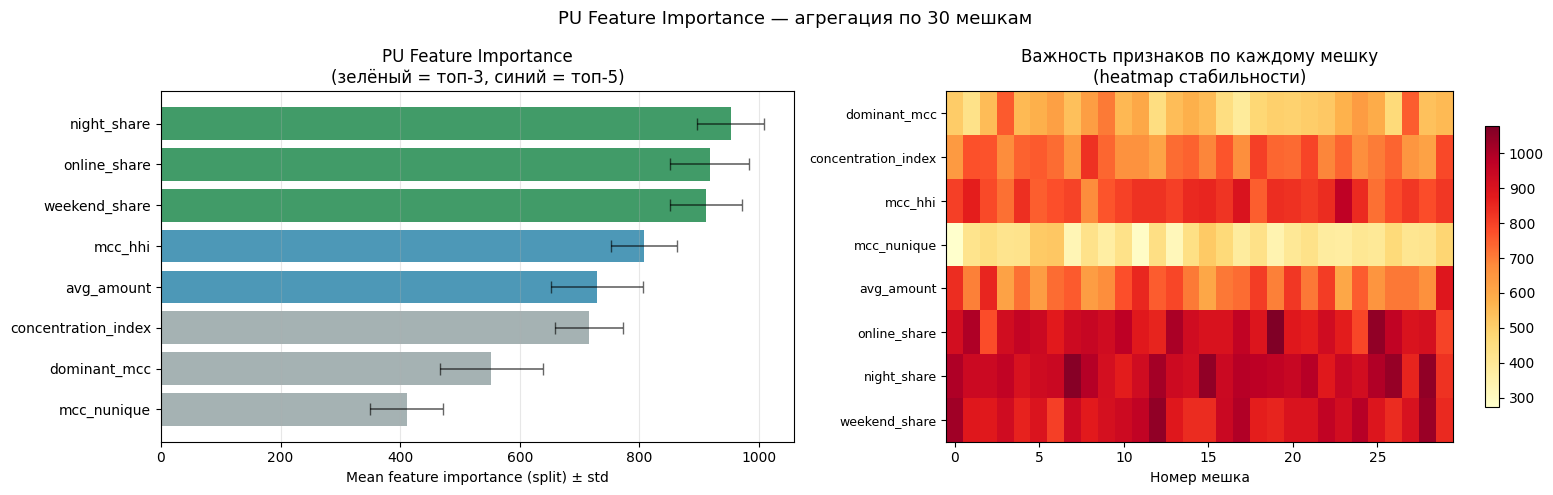


Стабильность признаков (CV = std/mean, меньше = стабильнее):


,feature,mean_importance,std_importance,cv
0,night_share,953.100,56.047,0.059
1,online_share,918.067,66.235,0.072
2,weekend_share,911.667,60.233,0.066
3,mcc_hhi,808.333,55.574,0.069
4,avg_amount,729.333,76.444,0.105
5,concentration_index,715.833,56.359,0.079
6,dominant_mcc,552.733,85.440,0.155
7,mcc_nunique,410.933,60.662,0.148


In [17]:
def extract_bag_importances(models: list, features: list) -> pd.DataFrame:
    """
    Агрегирует feature_importances_ по всем bag-моделям.

    Каждый bag — Pipeline с шагами ['pre', 'clf'].
    После ColumnTransformer порядок признаков: сначала WOE (1 колонка), затем числовые.
    """
    cat_f      = CAT_FEATURE if CAT_FEATURE in features else None
    num_f      = [f for f in features if f != CAT_FEATURE]
    feat_names = ([cat_f] if cat_f else []) + num_f

    all_imp = np.array([m.named_steps['clf'].feature_importances_ for m in models])
    # all_imp.shape = (n_bags, n_features)

    return pd.DataFrame({
        'feature':         feat_names,
        'mean_importance': all_imp.mean(axis=0),
        'std_importance':  all_imp.std(axis=0),
        'min_importance':  all_imp.min(axis=0),
        'max_importance':  all_imp.max(axis=0),
    }).sort_values('mean_importance', ascending=False).reset_index(drop=True)


pu_feat_imp = extract_bag_importances(pu_models, CLEAN_FEATURES)
print('=== Feature Importance PU (среднее по 30 мешкам) ===')
display(pu_feat_imp.round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Барчарт: mean importance ± std
ax1 = axes[0]
colors_imp = ['#1f8a4e' if i < 3 else '#2E86AB' if i < 5 else '#95a5a6'
              for i in range(len(pu_feat_imp))]
ax1.barh(pu_feat_imp['feature'], pu_feat_imp['mean_importance'],
         xerr=pu_feat_imp['std_importance'],
         color=colors_imp, alpha=0.85, capsize=4,
         error_kw={'linewidth': 1.2, 'alpha': 0.6})
ax1.set_xlabel('Mean feature importance (split) ± std')
ax1.set_title('PU Feature Importance\n(зелёный = топ-3, синий = топ-5)')
ax1.invert_yaxis()
ax1.grid(alpha=0.3, axis='x')

# Heatmap: importance по каждому из N_BAGS мешков — видна стабильность признаков
cat_f      = CAT_FEATURE if CAT_FEATURE in CLEAN_FEATURES else None
num_f      = [f for f in CLEAN_FEATURES if f != CAT_FEATURE]
feat_names = ([cat_f] if cat_f else []) + num_f

bag_imp_matrix = np.array([m.named_steps['clf'].feature_importances_ for m in pu_models])

ax2 = axes[1]
im = ax2.imshow(bag_imp_matrix.T, aspect='auto', cmap='YlOrRd')
ax2.set_yticks(range(len(feat_names)))
ax2.set_yticklabels(feat_names, fontsize=9)
ax2.set_xlabel('Номер мешка')
ax2.set_title('Важность признаков по каждому мешку\n(heatmap стабильности)')
plt.colorbar(im, ax=ax2, shrink=0.8)

plt.suptitle('PU Feature Importance — агрегация по 30 мешкам', fontsize=13)
plt.tight_layout()
plt.show()

# Коэффициент вариации: чем ниже, тем стабильнее признак от мешка к мешку
pu_feat_imp['cv'] = pu_feat_imp['std_importance'] / pu_feat_imp['mean_importance'].clip(1)
print('\nСтабильность признаков (CV = std/mean, меньше = стабильнее):')
display(pu_feat_imp[['feature', 'mean_importance', 'std_importance', 'cv']].round(3))


### 6.7 Feature Selection для PU

Вопрос: можно ли выбросить менее важные признаки без потери качества?

Метрика сравнения — **ранговая корреляция Спирмена** между полной моделью и урезанной. Если топ-100 карт почти совпадают (корреляция > 0.95), признак можно удалить. Дополнительно проверяем **Precision@K** через B2B-эвристику.

Уменьшение числа признаков важно не только для скорости: меньше признаков — меньше инфраструктуры для их вычисления в проде.



── Топ-5 по importance (5 признаков): ['night_share', 'online_share', 'weekend_share', 'mcc_hhi', 'avg_amount']
  Bag  5/30   mean_prob = 0.002
  Bag 10/30   mean_prob = 0.002
  Bag 15/30   mean_prob = 0.002
  Bag 20/30   mean_prob = 0.002
  Bag 25/30   mean_prob = 0.002
  Bag 30/30   mean_prob = 0.002

── Топ-4 по importance (4 признаков): ['night_share', 'online_share', 'weekend_share', 'mcc_hhi']
  Bag  5/30   mean_prob = 0.003
  Bag 10/30   mean_prob = 0.002
  Bag 15/30   mean_prob = 0.003
  Bag 20/30   mean_prob = 0.002
  Bag 25/30   mean_prob = 0.002
  Bag 30/30   mean_prob = 0.003

── Топ-3 по importance (3 признаков): ['night_share', 'online_share', 'weekend_share']
  Bag  5/30   mean_prob = 0.020
  Bag 10/30   mean_prob = 0.020
  Bag 15/30   mean_prob = 0.020
  Bag 20/30   mean_prob = 0.020
  Bag 25/30   mean_prob = 0.020
  Bag 30/30   mean_prob = 0.020

=== Feature Selection — сравнение наборов признаков ===


,n_features,rank_corr,prec@50,prec@100,prec@200
label,,,,,
Все 8 признаков (baseline),8,1.0000,0.22,0.25,0.265
Топ-5 по importance,5,0.6583,0.30,0.31,0.330
Топ-4 по importance,4,0.4874,0.28,0.27,0.295
Топ-3 по importance,3,0.6822,0.78,0.81,0.810


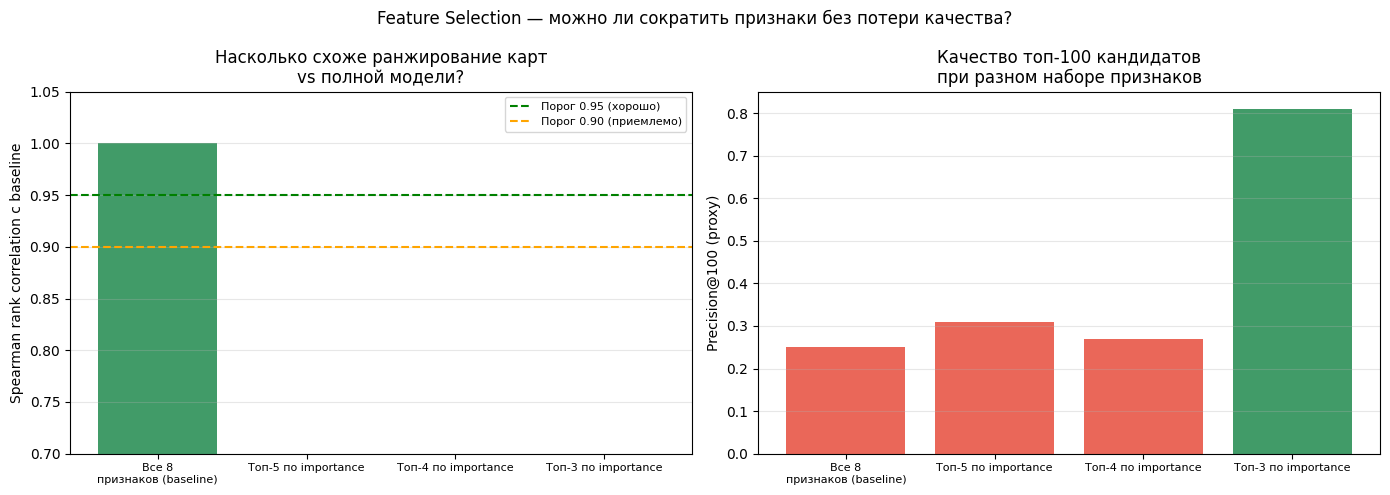


→ Лучший компактный набор: 3
  Ранговая корреляция с baseline: 0.6822
  Precision@100: 0.8100
  Экономия: 5 признаков из 8


In [18]:
def run_pu_subset(features: list, label: str, n_bags: int = N_BAGS) -> dict:
    """
    Обучает PU на заданном наборе признаков и возвращает метрики сравнения с baseline.
    Использует те же X_pos_pu, X_unl_pu, agg_con_reset что и основная модель.
    """
    probas = bagging_pu(
        X_pos=X_pos_pu, X_unl=X_unl_pu,
        X_score=agg_con_reset, features=features,
    )

    rank_corr = pd.Series(probas).rank(ascending=False).corr(
        agg_con_reset[MAIN_PU_COL].rank(ascending=False), method='spearman'
    )

    tmp = agg_con_reset.copy()
    tmp['_proba'] = probas
    def prec_at_k(k):
        return tmp.nlargest(k, '_proba').apply(looks_like_business, axis=1).mean()

    return {
        'label':      label,
        'n_features': len(features),
        'features':   features,
        'rank_corr':  round(rank_corr, 4),
        'prec@50':    round(prec_at_k(50),  4),
        'prec@100':   round(prec_at_k(100), 4),
        'prec@200':   round(prec_at_k(200), 4),
    }


# Наборы признаков для сравнения — в порядке убывания mean_importance из 6.6
top_features_ranked = pu_feat_imp['feature'].tolist()

feature_subsets = {
    f'Все {len(CLEAN_FEATURES)} признаков (baseline)': CLEAN_FEATURES,
    'Топ-5 по importance': top_features_ranked[:5],
    'Топ-4 по importance': top_features_ranked[:4],
    'Топ-3 по importance': top_features_ranked[:3],
}

# Baseline считаем из уже посчитанных вероятностей — не перезапускаем ансамбль
def prec_at_k_col(col, k):
    return agg_con_reset.nlargest(k, col).apply(looks_like_business, axis=1).mean()

fs_results = [{
    'label':      f'Все {len(CLEAN_FEATURES)} признаков (baseline)',
    'n_features': len(CLEAN_FEATURES),
    'features':   CLEAN_FEATURES,
    'rank_corr':  1.0000,
    'prec@50':    round(prec_at_k_col(MAIN_PU_COL, 50),  4),
    'prec@100':   round(prec_at_k_col(MAIN_PU_COL, 100), 4),
    'prec@200':   round(prec_at_k_col(MAIN_PU_COL, 200), 4),
}]

for label, feats in list(feature_subsets.items())[1:]:
    print(f'\n── {label} ({len(feats)} признаков): {feats}')
    fs_results.append(run_pu_subset(feats, label))

fs_df = pd.DataFrame(fs_results).drop(columns='features')
print('\n=== Feature Selection — сравнение наборов признаков ===')
display(fs_df.set_index('label').round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels_fs  = [r['label'].replace(' признаков', '\nпризнаков') for r in fs_results]
rank_corrs = [r['rank_corr'] for r in fs_results]
prec100    = [r['prec@100']  for r in fs_results]
x_fs       = np.arange(len(labels_fs))

axes[0].bar(x_fs, rank_corrs,
            color=['#1f8a4e' if v >= 0.95 else '#e67e22' if v >= 0.90
                   else '#e74c3c' for v in rank_corrs], alpha=0.85)
axes[0].axhline(0.95, color='green',  linestyle='--', linewidth=1.5, label='Порог 0.95 (хорошо)')
axes[0].axhline(0.90, color='orange', linestyle='--', linewidth=1.5, label='Порог 0.90 (приемлемо)')
axes[0].set_xticks(x_fs)
axes[0].set_xticklabels(labels_fs, fontsize=8)
axes[0].set_ylim(0.7, 1.05)
axes[0].set_ylabel('Spearman rank correlation с baseline')
axes[0].set_title('Насколько схоже ранжирование карт\nvs полной модели?')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3, axis='y')

axes[1].bar(x_fs, prec100,
            color=['#1f8a4e' if v >= max(prec100) * 0.95
                   else '#e67e22' if v >= max(prec100) * 0.90
                   else '#e74c3c' for v in prec100], alpha=0.85)
axes[1].set_xticks(x_fs)
axes[1].set_xticklabels(labels_fs, fontsize=8)
axes[1].set_ylabel('Precision@100 (proxy)')
axes[1].set_title('Качество топ-100 кандидатов\nпри разном наборе признаков')
axes[1].grid(alpha=0.3, axis='y')

plt.suptitle('Feature Selection — можно ли сократить признаки без потери качества?', fontsize=12)
plt.tight_layout()
plt.show()

best_small = fs_df[fs_df['n_features'] < len(CLEAN_FEATURES)].sort_values('rank_corr', ascending=False).iloc[0]
print(f'\n→ Лучший компактный набор: {best_small.name}')
print(f'  Ранговая корреляция с baseline: {best_small["rank_corr"]:.4f}')
print(f'  Precision@100: {best_small["prec@100"]:.4f}')
print(f'  Экономия: {len(CLEAN_FEATURES) - int(best_small["n_features"])} признаков из {len(CLEAN_FEATURES)}')


### 6.8 Оптимизация гиперпараметров PU (Grid Search)

Четыре параметра, которые влияют на качество PU Bagging:

| Параметр | Текущее | Что регулирует |
|---|---|---|
| `n_bags` | 30 | Стабильность ансамбля vs скорость обучения |
| `n_estimators` | 200 | Ёмкость каждой bag-модели |
| `num_leaves` | 31 | Сложность отдельных деревьев |
| `learning_rate` | 0.05 | Шаг обучения LightGBM |

Оптимизируем по **Precision@100** (прокси-метрика качества кандидатов) с контролем по ранговой корреляции: хорошая конфигурация не должна кардинально менять порядок карт относительно baseline.


In [19]:
# Лучший набор признаков из раздела 6.7 (обновляется автоматически)
BEST_FEATURES = top_features_ranked[:5]
print(f'Оптимизируем на признаках: {BEST_FEATURES}')


def run_pu_config(n_bags: int, n_estimators: int,
                  num_leaves: int, learning_rate: float) -> dict:
    """
    Обучает PU с заданными гиперпараметрами и возвращает Precision@100 и rank_corr.
    Переиспользует bagging_pu — логика bagging loop не дублируется.
    """
    probas = bagging_pu(
        X_pos=X_pos_pu, X_unl=X_unl_pu, X_score=agg_con_reset,
        features=BEST_FEATURES,
        n_bags=n_bags, n_estimators=n_estimators,
        num_leaves=num_leaves, learning_rate=learning_rate,
    )
    rank_corr = pd.Series(probas).rank(ascending=False).corr(
        agg_con_reset[MAIN_PU_COL].rank(ascending=False), method='spearman'
    )
    tmp       = agg_con_reset.copy()
    tmp['_p'] = probas
    prec100   = tmp.nlargest(100, '_p').apply(looks_like_business, axis=1).mean()

    return {
        'n_bags': n_bags, 'n_estimators': n_estimators,
        'num_leaves': num_leaves, 'learning_rate': learning_rate,
        'rank_corr': round(rank_corr, 4),
        'prec@100':  round(prec100,   4),
    }


# Grid: (n_bags, n_estimators, num_leaves, learning_rate)
grid = [
    (10,  200, 31, 0.05),
    (15,  200, 31, 0.05),
    (20,  200, 31, 0.05),   # меньше мешков — быстрее, но нестабильнее
    (30,  200, 31, 0.05),   # baseline конфигурация
    (30,  100, 31, 0.05),   # меньше деревьев
    (30,  300, 31, 0.05),   # больше деревьев
    (30,  200, 15, 0.05),   # проще деревья
    (30,  200, 63, 0.05),   # сложнее деревья
    (30,  200, 31, 0.10),   # быстрый learning rate
    (20,  150, 15, 0.10),   # лёгкая быстрая конфигурация
]

gs_results = []
for idx, (nb_, ne_, nl_, lr_) in enumerate(grid):
    print(f'[{idx+1}/{len(grid)}] n_bags={nb_:2d} n_est={ne_:3d} '
          f'num_leaves={nl_:2d} lr={lr_}  ', end='')
    res = run_pu_config(nb_, ne_, nl_, lr_)
    gs_results.append(res)
    print(f'→ rank_corr={res["rank_corr"]:.4f}  prec@100={res["prec@100"]:.4f}')

gs_df = pd.DataFrame(gs_results).sort_values('prec@100', ascending=False).reset_index(drop=True)
print('\n=== Grid Search — результаты (сортировка по Precision@100) ===')
display(gs_df)


Оптимизируем на признаках: ['night_share', 'online_share', 'weekend_share', 'mcc_hhi', 'avg_amount']
[1/10] n_bags=10 n_est=200 num_leaves=31 lr=0.05    Bag  5/10   mean_prob = 0.002
  Bag 10/10   mean_prob = 0.002
→ rank_corr=0.3890  prec@100=0.2900
[2/10] n_bags=15 n_est=200 num_leaves=31 lr=0.05    Bag  5/15   mean_prob = 0.002
  Bag 10/15   mean_prob = 0.002
  Bag 15/15   mean_prob = 0.002
→ rank_corr=0.5729  prec@100=0.2700
[3/10] n_bags=20 n_est=200 num_leaves=31 lr=0.05    Bag  5/20   mean_prob = 0.002
  Bag 10/20   mean_prob = 0.002
  Bag 15/20   mean_prob = 0.002
  Bag 20/20   mean_prob = 0.002
→ rank_corr=0.6245  prec@100=0.2800
[4/10] n_bags=30 n_est=200 num_leaves=31 lr=0.05    Bag  5/30   mean_prob = 0.002
  Bag 10/30   mean_prob = 0.002
  Bag 15/30   mean_prob = 0.002
  Bag 20/30   mean_prob = 0.002
  Bag 25/30   mean_prob = 0.002
  Bag 30/30   mean_prob = 0.002
→ rank_corr=0.6583  prec@100=0.3100
[5/10] n_bags=30 n_est=100 num_leaves=31 lr=0.05    Bag  5/30   mean_prob =

,n_bags,n_estimators,num_leaves,learning_rate,rank_corr,prec@100
0,30,200,63,0.05,0.3844,0.33
1,30,300,31,0.05,0.6115,0.33
2,30,200,31,0.10,0.6191,0.32
3,30,200,31,0.05,0.6583,0.31
4,30,200,15,0.05,0.6498,0.29
5,10,200,31,0.05,0.3890,0.29
6,20,150,15,0.10,0.6268,0.28
7,20,200,31,0.05,0.6245,0.28
8,15,200,31,0.05,0.5729,0.27
9,30,100,31,0.05,0.4133,0.27


### 6.9 Итоговый оптимизированный PU

Берём лучшую конфигурацию из Grid Search и сравниваем с baseline.


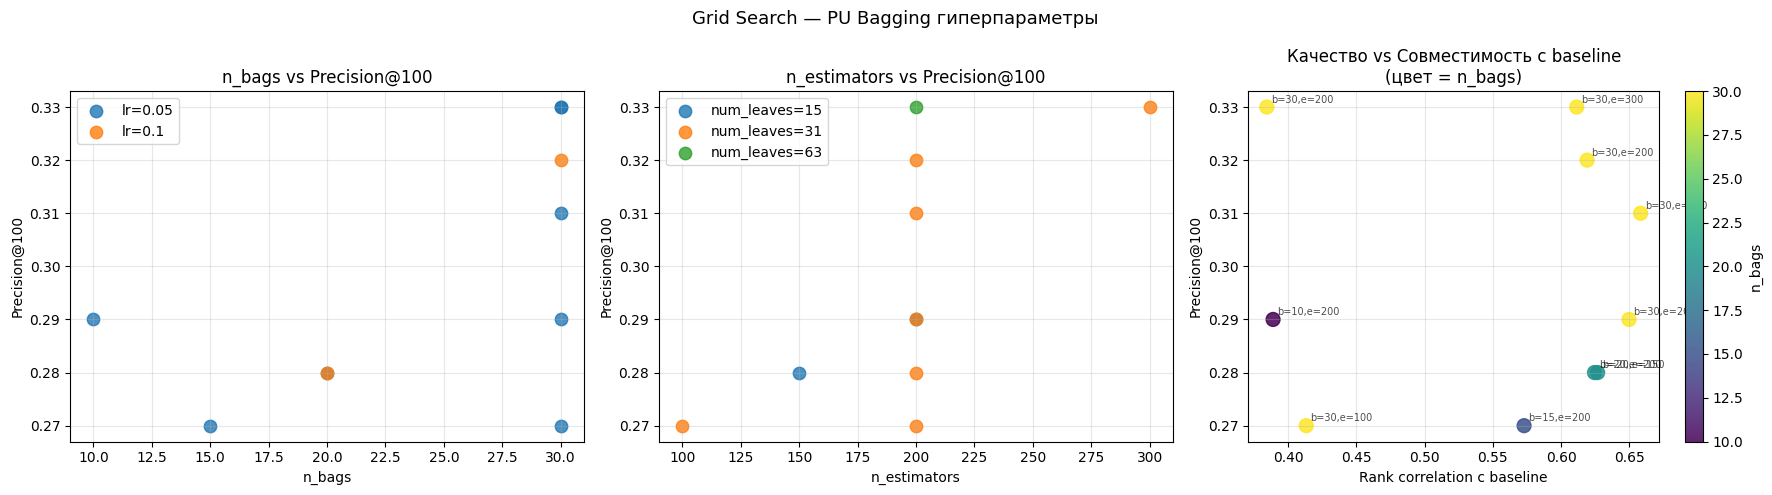

╔══════════════════════════════════════════════════════╗
║         ИТОГ ОПТИМИЗАЦИИ PU BAGGING                 ║
╠══════════════════════════════════════════════════════╣
║  Baseline : n_bags=30  n_est=200  leaves=31  lr=0.05
║             prec@100=0.3100  rank_corr=0.6583
║
║  Лучший   : n_bags=30  n_est=200  leaves=63  lr=0.05
║             prec@100=0.3300  rank_corr=0.3844
║
║  Признаки : 8 → 5 (убрано 3)
║  Мешков   : 30 → 30 (0% быстрее)
║  Деревьев : 200 → 200
╚══════════════════════════════════════════════════════╝

Топ признаков для оптимизированного PU:
  1. night_share                    importance=953.1  cv=0.059
  2. online_share                   importance=918.1  cv=0.072
  3. weekend_share                  importance=911.7  cv=0.066
  4. mcc_hhi                        importance=808.3  cv=0.069
  5. avg_amount                     importance=729.3  cv=0.105


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# n_bags vs Precision@100 — сгруппировано по learning_rate
ax1 = axes[0]
for lr_val, grp in gs_df.groupby('learning_rate'):
    ax1.scatter(grp['n_bags'], grp['prec@100'], label=f'lr={lr_val}', s=80, alpha=0.8)
ax1.set_xlabel('n_bags')
ax1.set_ylabel('Precision@100')
ax1.set_title('n_bags vs Precision@100')
ax1.legend()
ax1.grid(alpha=0.3)

# n_estimators vs Precision@100 — сгруппировано по num_leaves
ax2 = axes[1]
for nl_val, grp in gs_df.groupby('num_leaves'):
    ax2.scatter(grp['n_estimators'], grp['prec@100'], label=f'num_leaves={nl_val}', s=80, alpha=0.8)
ax2.set_xlabel('n_estimators')
ax2.set_ylabel('Precision@100')
ax2.set_title('n_estimators vs Precision@100')
ax2.legend()
ax2.grid(alpha=0.3)

# Фронт Парето: rank_corr vs Precision@100 — лучшие конфигурации в правом верхнем углу
ax3 = axes[2]
sc = ax3.scatter(gs_df['rank_corr'], gs_df['prec@100'],
                 c=gs_df['n_bags'], cmap='viridis', s=100, alpha=0.85)
for _, row in gs_df.iterrows():
    ax3.annotate(f"b={int(row['n_bags'])},e={int(row['n_estimators'])}",
                 (row['rank_corr'], row['prec@100']),
                 fontsize=7, alpha=0.7, xytext=(3, 3), textcoords='offset points')
ax3.set_xlabel('Rank correlation с baseline')
ax3.set_ylabel('Precision@100')
ax3.set_title('Качество vs Совместимость с baseline\n(цвет = n_bags)')
ax3.grid(alpha=0.3)
plt.colorbar(sc, ax=ax3, label='n_bags')

plt.suptitle('Grid Search — PU Bagging гиперпараметры', fontsize=13)
plt.tight_layout()
plt.show()

# Итоговое резюме
best_cfg     = gs_df.iloc[0]
baseline_cfg = gs_df[
    (gs_df['n_bags'] == N_BAGS) & (gs_df['n_estimators'] == 200) &
    (gs_df['num_leaves'] == 31) & (gs_df['learning_rate'] == 0.05)
]

print('╔══════════════════════════════════════════════════════╗')
print('║         ИТОГ ОПТИМИЗАЦИИ PU BAGGING                 ║')
print('╠══════════════════════════════════════════════════════╣')
if not baseline_cfg.empty:
    b = baseline_cfg.iloc[0]
    print(f'║  Baseline : n_bags={int(b.n_bags):2d}  n_est={int(b.n_estimators):3d}  '
          f'leaves={int(b.num_leaves):2d}  lr={b.learning_rate}')
    print(f'║             prec@100={b["prec@100"]:.4f}  rank_corr={b.rank_corr:.4f}')
    print('║')
print(f'║  Лучший   : n_bags={int(best_cfg.n_bags):2d}  n_est={int(best_cfg.n_estimators):3d}  '
      f'leaves={int(best_cfg.num_leaves):2d}  lr={best_cfg.learning_rate}')
print(f'║             prec@100={best_cfg["prec@100"]:.4f}  rank_corr={best_cfg.rank_corr:.4f}')
print('║')
print(f'║  Признаки : {len(CLEAN_FEATURES)} → {len(BEST_FEATURES)} '
      f'(убрано {len(CLEAN_FEATURES)-len(BEST_FEATURES)})')
print(f'║  Мешков   : {N_BAGS} → {int(best_cfg.n_bags)} '
      f'({int((1 - best_cfg.n_bags/N_BAGS)*100):.0f}% быстрее)')
print(f'║  Деревьев : 200 → {int(best_cfg.n_estimators)}')
print('╚══════════════════════════════════════════════════════╝')
print()
print('Топ признаков для оптимизированного PU:')
for i, f in enumerate(BEST_FEATURES, 1):
    row = pu_feat_imp[pu_feat_imp['feature'] == f].iloc[0]
    print(f'  {i}. {f:<30} importance={row.mean_importance:.1f}  cv={row.cv:.3f}')


---
## 7. Сравнение всех трёх моделей

Финальное сопоставление на test-сете. Напоминаем: F1/Precision/Recall для PU измерены на **грязных метках** — часть «ложных позитивов» реально является бизнесами. Истинная ценность PU — в Precision@100 (раздел 6.5), а не в этих числах.


### 7.1 Сводная таблица метрик

In [21]:
comparison = pd.DataFrame({
    'Модель':      ['Logistic Regression', 'Naive LightGBM', 'PU Learning'],
    'ROC-AUC':     [lr_auc,      lgb_auc,      pu_auc],
    'Accuracy':    [lr_acc,      lgb_acc,      pu_acc],
    'F1 (binary)': [lr_f1_bin,   lgb_f1_bin,   pu_f1_bin],
    'F1 (macro)':  [lr_f1_macro, lgb_f1_macro, pu_f1_macro],
    'Precision':   [lr_prec,     lgb_prec,     pu_prec],
    'Recall':      [lr_rec,      lgb_rec,      pu_rec],
    'Threshold':   [lr_best_thr, lgb_best_thr, pu_best_thr],
}).round(4)

print('=' * 72)
print('СРАВНЕНИЕ МОДЕЛЕЙ — TEST SET (по разметке организаторов)')
print('=' * 72)
display(comparison.set_index('Модель'))


СРАВНЕНИЕ МОДЕЛЕЙ — TEST SET (по разметке организаторов)


,ROC-AUC,Accuracy,F1 (binary),F1 (macro),Precision,Recall,Threshold
Модель,,,,,,,
Logistic Regression,0.9999,0.9978,0.9953,0.9969,0.9958,0.9948,0.53
Naive LightGBM,1.0000,0.9989,0.9976,0.9984,0.9974,0.9978,0.18
PU Learning,1.0000,0.9988,0.9975,0.9984,0.9966,0.9984,0.60


### 7.2 ROC-кривые + барчарт метрик

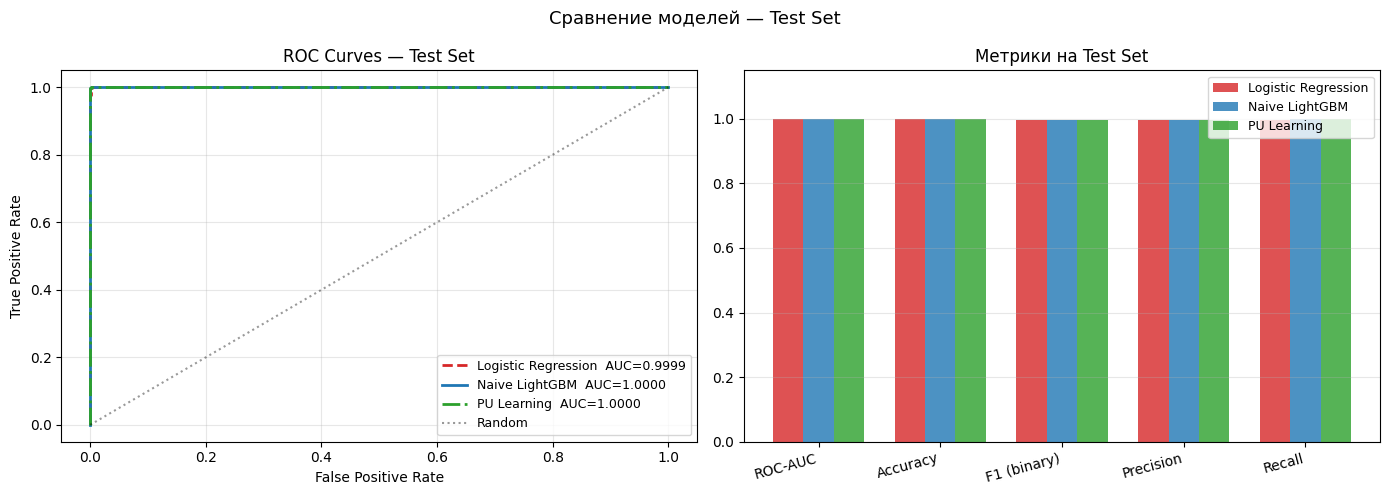

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
for name_, prob_, color_, ls_ in [
        ('Logistic Regression', lr_test_prob,  'tab:red',   '--'),
        ('Naive LightGBM',      lgb_test_prob, 'tab:blue',  '-'),
        ('PU Learning',         pu_test_prob,  'tab:green', '-.')]:
    fpr, tpr, _ = roc_curve(y_test, prob_)
    ax1.plot(fpr, tpr, color=color_, linestyle=ls_, linewidth=2,
             label=f'{name_}  AUC={roc_auc_score(y_test, prob_):.4f}')
ax1.plot([0, 1], [0, 1], 'k:', alpha=0.4, label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curves — Test Set')
ax1.legend(loc='lower right', fontsize=9)
ax1.grid(alpha=0.3)

ax2     = axes[1]
cols_m  = ['ROC-AUC', 'Accuracy', 'F1 (binary)', 'Precision', 'Recall']
rows    = comparison.set_index('Модель')
x       = np.arange(len(cols_m))
w       = 0.25

for i, (model_name, color_b) in enumerate(zip(rows.index, ['tab:red', 'tab:blue', 'tab:green'])):
    vals = [rows.loc[model_name, m] for m in cols_m]
    ax2.bar(x + i * w, vals, w, label=model_name, color=color_b, alpha=0.8)

ax2.set_xticks(x + w)
ax2.set_xticklabels(cols_m, rotation=15, ha='right')
ax2.set_ylim(0, 1.15)
ax2.set_title('Метрики на Test Set')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Сравнение моделей — Test Set', fontsize=13)
plt.tight_layout()
plt.show()


### 7.3 PU vs LightGBM — распределение вероятностей физлиц

Ключевой вопрос: видят ли две модели разных кандидатов? Scatter-plot карта-за-картой показывает, насколько хорошо модели согласуются.


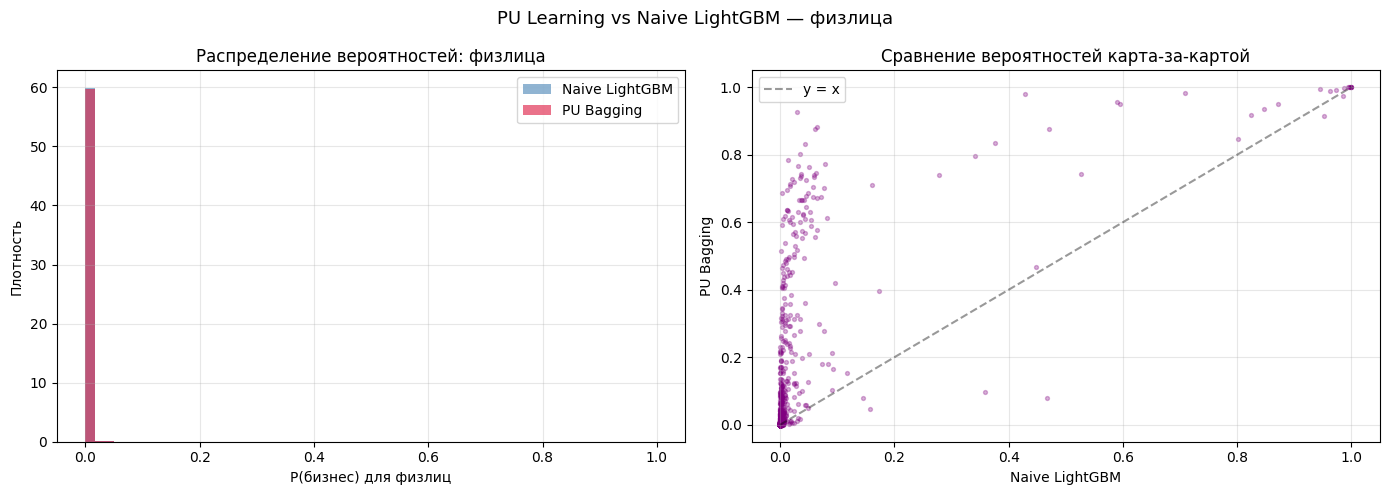

   Порог      LightGBM    PU Bagging
  p > 0.30:   LightGBM=   28   PU=  140
  p > 0.40:   LightGBM=   25   PU=  118
  p > 0.50:   LightGBM=   21   PU=   93
  p > 0.60:   LightGBM=   18   PU=   75
  p > 0.70:   LightGBM=   18   PU=   49
  p > 0.80:   LightGBM=   17   PU=   28
  p > 0.90:   LightGBM=   13   PU=   21


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.hist(agg_con_reset['ordinary_proba'], bins=60, alpha=0.6,
         color='steelblue', label='Naive LightGBM', density=True)
ax1.hist(agg_con_reset[MAIN_PU_COL], bins=60, alpha=0.6,
         color='crimson',   label='PU Bagging',    density=True)
ax1.set_xlabel('P(бизнес) для физлиц')
ax1.set_ylabel('Плотность')
ax1.set_title('Распределение вероятностей: физлица')
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = axes[1]
ax2.scatter(agg_con_reset['ordinary_proba'], agg_con_reset[MAIN_PU_COL],
            alpha=0.3, s=8, color='purple')
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='y = x')
ax2.set_xlabel('Naive LightGBM')
ax2.set_ylabel('PU Bagging')
ax2.set_title('Сравнение вероятностей карта-за-картой')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('PU Learning vs Naive LightGBM — физлица', fontsize=13)
plt.tight_layout()
plt.show()

# Сколько карт проходит разные пороги в каждой модели
print(f'{"Порог":>8}  {"LightGBM":>12}  {"PU Bagging":>12}')
for t in [0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]:
    n_ord = int((agg_con_reset['ordinary_proba'] > t).sum())
    n_pu  = int((agg_con_reset[MAIN_PU_COL] > t).sum())
    print(f'  p > {t:.2f}:   LightGBM={n_ord:5d}   PU={n_pu:5d}')


### 7.4 Экспорт кандидатов

In [24]:
export = hidden_pu[BASE_EXPORT_COLS + OPTIONAL_EXPORT_COLS].copy()
export[MAIN_PU_COL]      = export[MAIN_PU_COL].round(4)
export['ordinary_proba'] = export['ordinary_proba'].round(4)
export.to_csv('hidden_entrepreneurs_v8.csv', index=False)

print(f'Сохранено {len(export):,} карт-кандидатов → hidden_entrepreneurs_v8.csv')
print(f'  из них plausible_business=True: {hidden_pu["plausible_business"].sum()}')
display(export.head(10))


Сохранено 100 карт-кандидатов → hidden_entrepreneurs_v8.csv
  из них plausible_business=True: 25


,card_number,pu_proba,ordinary_proba,plausible_business,dominant_mcc,concentration_index,avg_amount,weekend_share
77408,5201491354169846,1.0000,0.9999,False,4111,6.500000,217102.438462,0.076923
65960,5211556274611016,0.9999,0.9998,False,7311,4.142857,404728.370690,0.155172
76020,5368291791007503,0.9999,0.9994,False,other,12.285714,281608.097674,0.186047
30143,5100611889266872,0.9999,0.9982,False,other,16.571429,168466.099138,0.120690
46785,5176512938679108,0.9999,0.9985,True,4816,14.714286,146180.718447,0.106796
72543,5168266771002940,0.9996,0.9964,True,4816,12.714286,327799.897753,0.112360
43893,5441020944586282,0.9995,0.9937,True,7311,6.750000,224755.738889,0.111111
65749,5486737863418710,0.9983,0.9867,False,other,12.833333,152134.727273,0.129870
34766,5338479914183213,0.9960,0.9448,True,7311,8.000000,236368.998214,0.142857
70187,5486025422486893,0.9905,0.9734,True,5099,5.571429,184827.597436,0.128205


---
## Выводы

| Модель | Сильные стороны | Ограничения |
|--------|-----------------|-------------|
| **Logistic Regression** | Интерпретируемые коэффициенты, объяснима стейкхолдерам | Линейная граница, ниже AUC |
| **Naive LightGBM** | Высокий AUC, нелинейные взаимодействия | Предполагает чистые метки класса 0 — это неверно |
| **PU Learning** | Правильная постановка, не штрафует скрытых предпринимателей | Медленнее (30 bags), вероятности в другом масштабе |

### Почему PU Learning — правильный выбор для этой задачи

В классической классификации модель получает сигнал «эта карта — потребитель» для всех карт без бизнес-метки. Часть из них — скрытые предприниматели. Модель явно обучается **занижать их скор**, что снижает recall именно для тех карт, которые мы хотим найти.

PU Learning признаёт: «мы знаем только positives; всё остальное — unlabeled». Карты, которые стабильно получают высокую вероятность при **любой** подвыборке негативов, не могут быть обычными потребителями — они кандидаты.

### Оперативные заметки

**Динамический порог (топ-N)** удобнее фиксированного: команда сама задаёт сколько карт готова проверить, а не подбирает магическое число на [0, 1].

**Proxy-precision** — единственная честная метрика для PU в данной задаче: ground truth для физлиц неизвестен, но B2B-эвристика даёт хорошую оценку насколько кандидаты действительно похожи на бизнес.
